### 1. Import packages

In [33]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import os
import warnings
warnings.filterwarnings("ignore")

from art.estimators.classification import CatBoostARTClassifier
from art.attacks.evasion import ZooAttack, HopSkipJump
from catboost import CatBoostClassifier

### 2. Load model and test data

In [32]:
# Load trained CatBoost model
cat_model = joblib.load('../../training/models/framework_cat_TVAE.pkl')

# Load test data
df_test = pd.read_csv('../../datasets/test_shap_66.csv')
X_test = df_test.drop(columns=['Label']).values
y_test = df_test['Label'].values.astype(int)

In [34]:
# Create ART classifier
classifier = CatBoostARTClassifier(
    model=cat_model,
    clip_values=(np.min(X_test), np.max(X_test)),
    nb_features=X_test.shape[1],
)

predictions = classifier.predict(X_test)
predictions = np.argmax(predictions, axis=1)
accuracy = accuracy_score(y_test, predictions)
print(f'Original Accuracy: {accuracy * 100:.2f}%')

Original Accuracy: 86.34%


In [35]:
def evaluate_attack(y_test, y_pred, attack_name):
    predictions = np.argmax(y_pred, axis=1)

    accuracy = accuracy_score(y_test, predictions) * 100
    f1 = f1_score(y_test, predictions, average='macro')
    precision = precision_score(y_test, predictions, average='macro') * 100
    recall = recall_score(y_test, predictions, average='macro') * 100

    print(f'--- {attack_name} ---')
    print(f'Accuracy: {accuracy:.2f}%')
    print(f'Precision: {precision:.2f}%')
    print(f'Recall: {recall:.2f}%')
    print(f'F1 Score: {f1:.4f}')

    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{attack_name} - Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

### 3. Evaluate original model on adversarial test samples

--- ZOO (before AT) ---
Accuracy: 27.27%
Precision: 29.88%
Recall: 27.27%
F1 Score: 0.2749


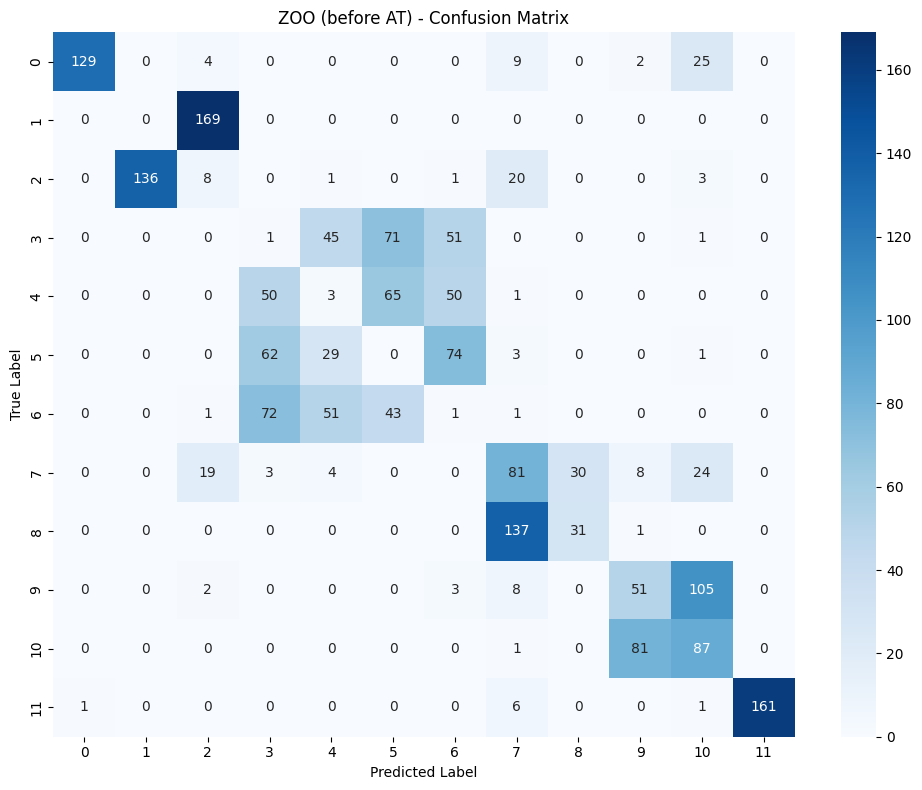

--- HSJA (before AT) ---
Accuracy: 10.70%
Precision: 5.54%
Recall: 10.70%
F1 Score: 0.0471


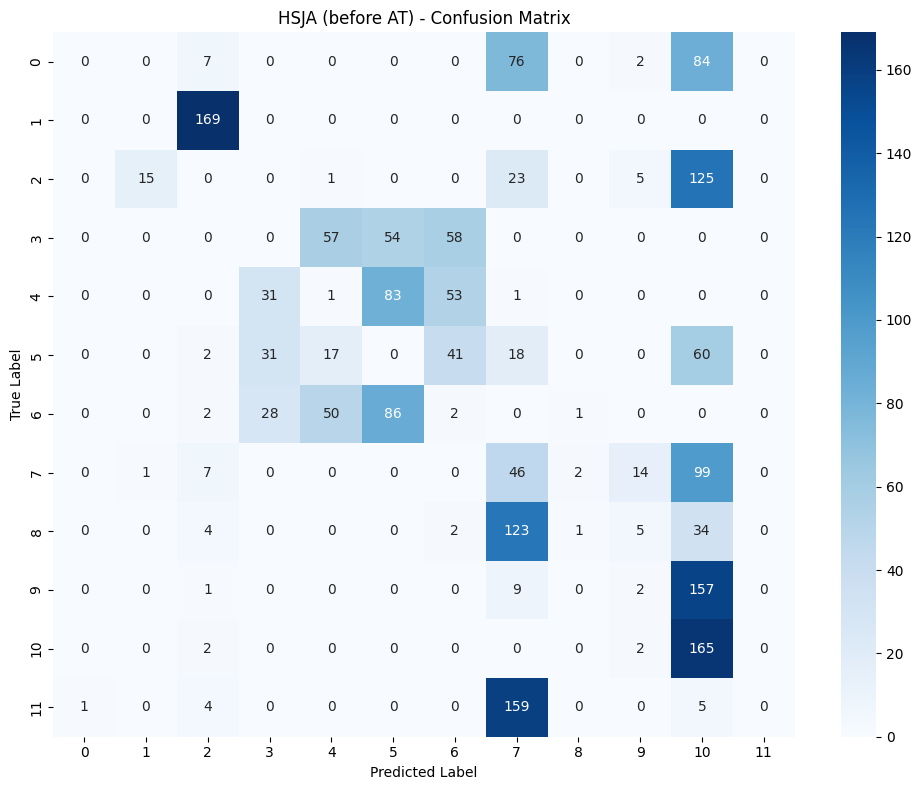

In [36]:
# Load adversarial test samples
df_zoo = pd.read_csv('../../adv_samples/adv_eval/cat/cat_zoo_adv.csv')
ZOO_samples = df_zoo.drop(columns=['Label']).values

df_hsja = pd.read_csv('../../adv_samples/adv_eval/cat/cat_hsja_adv.csv')
HSJA_samples = df_hsja.drop(columns=['Label']).values

preds_adv = classifier.predict(ZOO_samples)
evaluate_attack(y_test, preds_adv, 'ZOO (before AT)')

preds_adv = classifier.predict(HSJA_samples)
evaluate_attack(y_test, preds_adv, 'HSJA (before AT)')

### 4. Generate adversarial samples from training data

In [37]:
# Load train data
df_train = pd.read_csv('../../datasets/augment/train_tvae_9600.csv')
X_train = df_train.drop(columns=['Label']).values
y_train = df_train['Label'].values.astype(int)

ZOO on train data

In [38]:
attack = ZooAttack(
    classifier=classifier,
    confidence=0.0,
    targeted=False,
    learning_rate=1e-1,
    max_iter=50,
    binary_search_steps=2,
    initial_const=1e-3,
    abort_early=True,
    use_resize=False,
    use_importance=False,
    nb_parallel=10,
    batch_size=1,
    variable_h=0.02,
)

start_time = time.time()
ZOO_train_adv = attack.generate(x=X_train)
print("Runtime: ", time.time() - start_time, " seconds")

# Save
feature_names = df_train.columns[:-1].tolist()
df_adv = pd.DataFrame(ZOO_train_adv, columns=feature_names)
df_adv['Label'] = y_train
df_adv.to_csv('../../adv_samples/adv_training/cat/cat_zoo_train_adv.csv', index=False)

ZOO: 100%|██████████| 9600/9600 [01:50<00:00, 87.02it/s] 


Runtime:  110.49114894866943  seconds


HSJA on train data

In [39]:
attack = HopSkipJump(
    classifier=classifier,
    batch_size=64,
    targeted=False,
    norm=2,
    max_iter=2,
    max_eval=200,
    init_eval=10,
    init_size=10,
    verbose=True,
)

start_time = time.time()
HSJA_train_adv = attack.generate(x=X_train)
print("Runtime: ", time.time() - start_time, " seconds")

# Save
df_adv = pd.DataFrame(HSJA_train_adv, columns=feature_names)
df_adv['Label'] = y_train
df_adv.to_csv('../../adv_samples/adv_training/cat/cat_hsja_train_adv.csv', index=False)

HopSkipJump: 100%|██████████| 9600/9600 [01:06<00:00, 144.76it/s]


Runtime:  66.49853897094727  seconds


### 5. Adversarial training — retrain CatBoost

In [ ]:
# Load adversarial training samples
df_zoo_train = pd.read_csv('../../adv_samples/adv_training/cat/cat_zoo_train_adv.csv')
df_hsja_train = pd.read_csv('../../adv_samples/adv_training/cat/cat_hsja_train_adv.csv')

ZOO_train_adv = df_zoo_train.drop(columns=['Label']).values
HSJA_train_adv = df_hsja_train.drop(columns=['Label']).values

# Merge: original train + ZOO adv + HSJA adv
adv_samples = np.concatenate((ZOO_train_adv, HSJA_train_adv), axis=0)
train_data = np.concatenate((X_train, adv_samples), axis=0)
train_labels = np.concatenate((y_train, y_train, y_train), axis=0)

print(f'Train data: {train_data.shape}')
print(f'Train labels: {train_labels.shape}')

In [ ]:
# Retrain CatBoost with original hyperparameters
print('CatBoost adversarial training...')

features = df_train.columns[:-1].tolist()
train_x = pd.DataFrame(train_data, columns=features)
train_y = pd.Series(train_labels, name='Label')

categorical_var = np.where(train_x.dtypes != np.float64)[0]

model_cat = CatBoostClassifier(
    iterations=5000,
    depth=15,
    learning_rate=0.65,
    loss_function='MultiClass',
    eval_metric='TotalF1',
    od_type='Iter',
    od_wait=30,
    random_seed=42,
)

cat_model_at = model_cat.fit(
    train_x,
    train_y,
    cat_features=list(categorical_var),
    plot=False,
)
print('Done.')

joblib.dump(cat_model_at, '../../defense/models/framework_cat_TVAE_at.pkl')
print('Saved to defense/models/framework_cat_TVAE_at.pkl')

### 6. Evaluate retrained model

In [ ]:
# Load retrained model
cat_model_at = joblib.load('../../defense/models/framework_cat_TVAE_at.pkl')

classifier_at = CatBoostARTClassifier(
    model=cat_model_at,
    clip_values=(np.min(X_test), np.max(X_test)),
    nb_features=X_test.shape[1],
)

# Evaluate on original test data
preds_orig = classifier_at.predict(X_test)
evaluate_attack(y_test, preds_orig, 'Original (after AT)')

# Evaluate on ZOO adversarial test samples
preds_adv = classifier_at.predict(ZOO_samples)
evaluate_attack(y_test, preds_adv, 'ZOO (after AT)')

# Evaluate on HSJA adversarial test samples
preds_adv = classifier_at.predict(HSJA_samples)
evaluate_attack(y_test, preds_adv, 'HSJA (after AT)')

### 7. ASR comparison

In [ ]:
# Before AT
preds_before = classifier.predict(X_test)
y_pred_before = np.argmax(preds_before, axis=1)
correct_before = np.where(y_test == y_pred_before)[0]

preds_zoo_before = classifier.predict(ZOO_samples)
asr_zoo_before = np.sum(y_pred_before[correct_before] != np.argmax(preds_zoo_before, axis=1)[correct_before]) / len(correct_before) * 100

preds_hsja_before = classifier.predict(HSJA_samples)
asr_hsja_before = np.sum(y_pred_before[correct_before] != np.argmax(preds_hsja_before, axis=1)[correct_before]) / len(correct_before) * 100

# After AT
preds_after = classifier_at.predict(X_test)
y_pred_after = np.argmax(preds_after, axis=1)
correct_after = np.where(y_test == y_pred_after)[0]

preds_zoo_after = classifier_at.predict(ZOO_samples)
asr_zoo_after = np.sum(y_pred_after[correct_after] != np.argmax(preds_zoo_after, axis=1)[correct_after]) / len(correct_after) * 100

preds_hsja_after = classifier_at.predict(HSJA_samples)
asr_hsja_after = np.sum(y_pred_after[correct_after] != np.argmax(preds_hsja_after, axis=1)[correct_after]) / len(correct_after) * 100

print(f'ZOO  ASR: {asr_zoo_before:.2f}% -> {asr_zoo_after:.2f}%')
print(f'HSJA ASR: {asr_hsja_before:.2f}% -> {asr_hsja_after:.2f}%')

## Retrain CAT: WB from ResDNN+LSTM + BB from CAT itself (Multi-source AT)

In [69]:
# ── Multi-source AT: ResDNN WB + LSTM WB ──
ADV_SOURCES = {
    'resdnn': {
        'dir': '../../adv_samples/adv_training/resdnn',
        'prefix': 'resdnn',
        'attacks': [
            ('fgsm',     4.0),
            ('pgd',      3.0),
            ('deepfool', 5.0),
            ('cw',       2.0),
            ('mim',      3.0),
        ],
    },
    'lstm': {
        'dir': '../../adv_samples/adv_training/lstm',
        'prefix': 'lstm',
        'attacks': [
            ('fgsm',     4.0),
            ('pgd',      3.0),
            ('deepfool', 5.0),
            ('jsma',     1.5),
            ('mim',      3.0),
        ],
    },
}

# ── Config ──
CLEAN_ADV_RATIO = 10  # adv = 50% of clean → 4800 adv total
n_clean = len(X_train)
n_adv_budget = int(n_clean * CLEAN_ADV_RATIO)

# Split budget: 50/50 between resdnn and lstm
SOURCE_BUDGET_RATIO = {'resdnn': 0.5, 'lstm': 0.5}

rng = np.random.RandomState(42)
parts_X, parts_y = [], []

for src_name, src_cfg in ADV_SOURCES.items():
    src_dir = src_cfg['dir']
    prefix = src_cfg['prefix']
    attacks = src_cfg['attacks']
    total_weight = sum(w for _, w in attacks)
    budget = int(n_adv_budget * SOURCE_BUDGET_RATIO[src_name])

    print(f'=== {src_name.upper()} (budget={budget}) ===')

    for atk_name, weight in attacks:
        path = os.path.join(src_dir, f'{prefix}_{atk_name}_train_adv.csv')
        if not os.path.exists(path):
            print(f'  [SKIP] {path}')
            continue

        df = pd.read_csv(path)
        X_atk = df.drop(columns=['Label']).values.astype(np.float32)
        y_atk = df['Label'].values.astype(int)

        n_sample = int(budget * weight / total_weight)
        n_sample = min(n_sample, len(X_atk))
        idx = rng.choice(len(X_atk), size=n_sample, replace=False)
        parts_X.append(X_atk[idx])
        parts_y.append(y_atk[idx])
        print(f'  {atk_name:>10s}: {len(X_atk)} -> {n_sample}  (weight={weight})')

    print()

# ── Merge & dedup ──
adv_X = np.concatenate(parts_X)
adv_y = np.concatenate(parts_y)

X_train_at = np.concatenate([X_train, adv_X])
y_train_at = np.concatenate([y_train, adv_y])

df_tmp = pd.DataFrame(X_train_at)
df_tmp['_lbl'] = y_train_at
n_before = len(df_tmp)
df_tmp = df_tmp.drop_duplicates()
X_train_at = df_tmp.drop(columns=['_lbl']).values.astype(np.float32)
y_train_at = df_tmp['_lbl'].values.astype(int)

print(f'Clean: {n_clean} | Adv: {len(adv_X)} | Dedup: {n_before - len(df_tmp)}')
print(f'AT train: {X_train_at.shape}')
print(f'\nLabel distribution:\n{pd.Series(y_train_at).value_counts().sort_index()}')

=== RESDNN (budget=48000) ===
        fgsm: 9600 -> 9600  (weight=4.0)
         pgd: 9600 -> 8470  (weight=3.0)
    deepfool: 9600 -> 9600  (weight=5.0)
          cw: 9600 -> 5647  (weight=2.0)
         mim: 9600 -> 8470  (weight=3.0)

=== LSTM (budget=48000) ===
        fgsm: 9600 -> 9600  (weight=4.0)
         pgd: 9600 -> 8727  (weight=3.0)
    deepfool: 9600 -> 9600  (weight=5.0)
        jsma: 9600 -> 4363  (weight=1.5)
         mim: 9600 -> 8727  (weight=3.0)

Clean: 9600 | Adv: 82804 | Dedup: 2248
AT train: (90156, 66)

Label distribution:
0     7253
1     7577
2     7650
3     7538
4     7498
5     7685
6     7467
7     7459
8     7573
9     7442
10    7460
11    7554
Name: count, dtype: int64


In [70]:
# Retrain CatBoost with adversarial training (multi-source: ResDNN + LSTM)
print('CatBoost adversarial training (ResDNN + LSTM)...')

cat_params = {
    "iterations": 5000,
    "depth": 8,
    "learning_rate": 0.05,
    "l2_leaf_reg": 3,
    "loss_function": "MultiClass",
    "task_type": "CPU",
    "thread_count": -1,
    "random_seed": 42,
    "eval_metric": "TotalF1",
    "od_type": "Iter",
    "od_wait": 1,
}

cat_model = CatBoostClassifier(**cat_params)

cat_model_at = cat_model.fit(
    X_train_at,
    y_train_at,
    plot=False,
)
print('Done.')

os.makedirs('../../defense/hybrid/models', exist_ok=True)
joblib.dump(cat_model_at, '../../defense/hybrid/models/framework_cat_multi_at.pkl')
print('Saved to defense/hybrid/models/framework_cat_multi_at.pkl')

CatBoost adversarial training (ResDNN + LSTM)...
0:	learn: 0.5821504	total: 293ms	remaining: 24m 25s
1:	learn: 0.6180446	total: 497ms	remaining: 20m 40s
2:	learn: 0.6253587	total: 674ms	remaining: 18m 43s
3:	learn: 0.6199404	total: 857ms	remaining: 17m 50s
4:	learn: 0.6292935	total: 1.04s	remaining: 17m 15s
5:	learn: 0.6442000	total: 1.32s	remaining: 18m 22s
6:	learn: 0.6386851	total: 1.56s	remaining: 18m 34s
7:	learn: 0.6470340	total: 1.74s	remaining: 18m 6s
8:	learn: 0.6499633	total: 1.92s	remaining: 17m 44s
9:	learn: 0.6501258	total: 2.11s	remaining: 17m 30s
10:	learn: 0.6555442	total: 2.29s	remaining: 17m 17s
11:	learn: 0.6564025	total: 2.46s	remaining: 17m 2s
12:	learn: 0.6603430	total: 2.64s	remaining: 16m 53s
13:	learn: 0.6657495	total: 2.82s	remaining: 16m 45s
14:	learn: 0.6659710	total: 3.01s	remaining: 16m 40s
15:	learn: 0.6722467	total: 3.19s	remaining: 16m 32s
16:	learn: 0.6718755	total: 3.36s	remaining: 16m 25s
17:	learn: 0.6824826	total: 3.53s	remaining: 16m 18s
18:	learn

### 8. Evaluate retrained CAT (ResDNN whitebox AT) on MLP Surrogate adversarial samples

--- Clean test (CAT retrained w/ ResDNN WB) ---
Accuracy: 81.41%
Precision: 81.29%
Recall: 81.41%
F1 Score: 0.8116


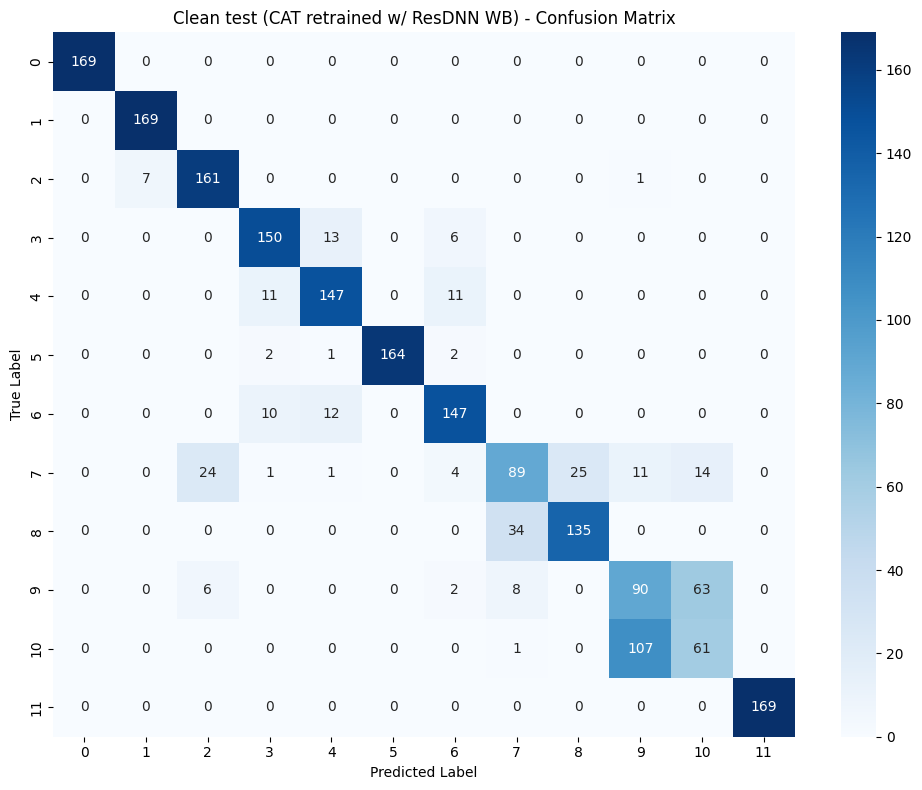

--- Surrogate MLP FGSM (CAT retrained w/ ResDNN WB) ---
Accuracy: 66.42%
Precision: 66.89%
Recall: 66.42%
F1 Score: 0.6574


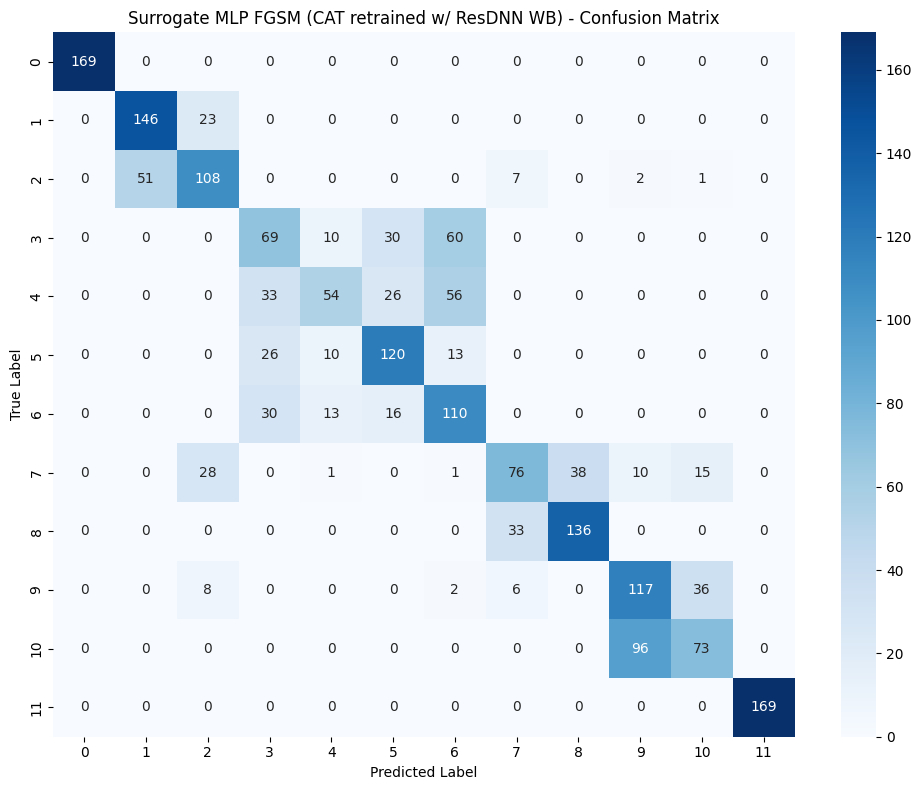

  ASR: 24.71%

--- Surrogate MLP PGD (CAT retrained w/ ResDNN WB) ---
Accuracy: 64.79%
Precision: 67.11%
Recall: 64.79%
F1 Score: 0.6448


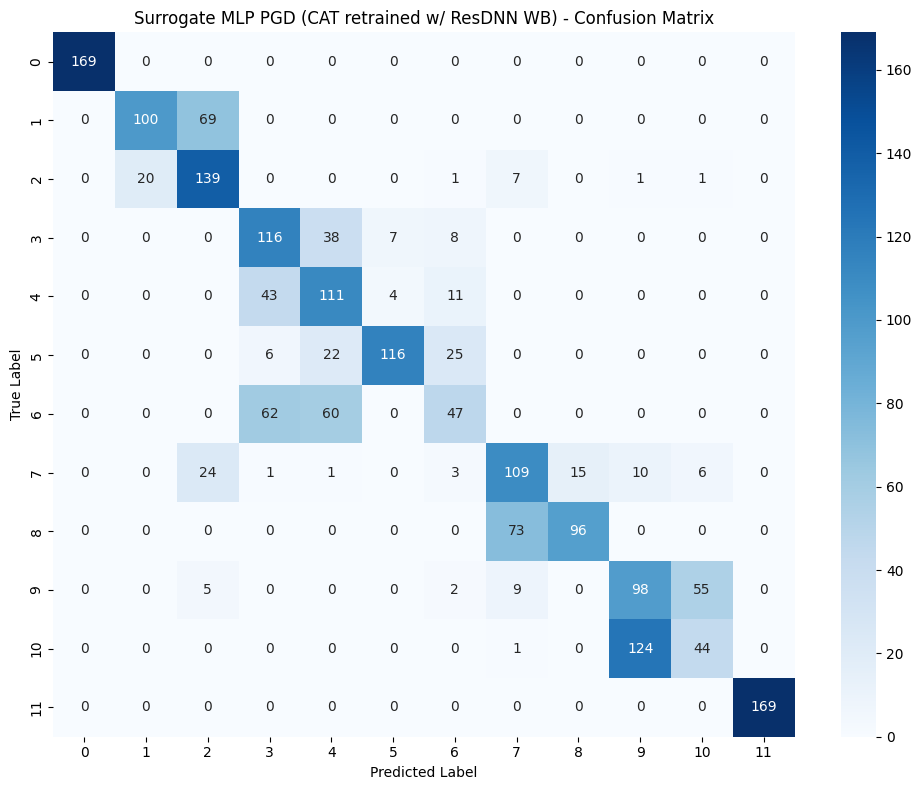

  ASR: 25.74%

--- Surrogate MLP BIM (CAT retrained w/ ResDNN WB) ---
Accuracy: 66.17%
Precision: 67.32%
Recall: 66.17%
F1 Score: 0.6598


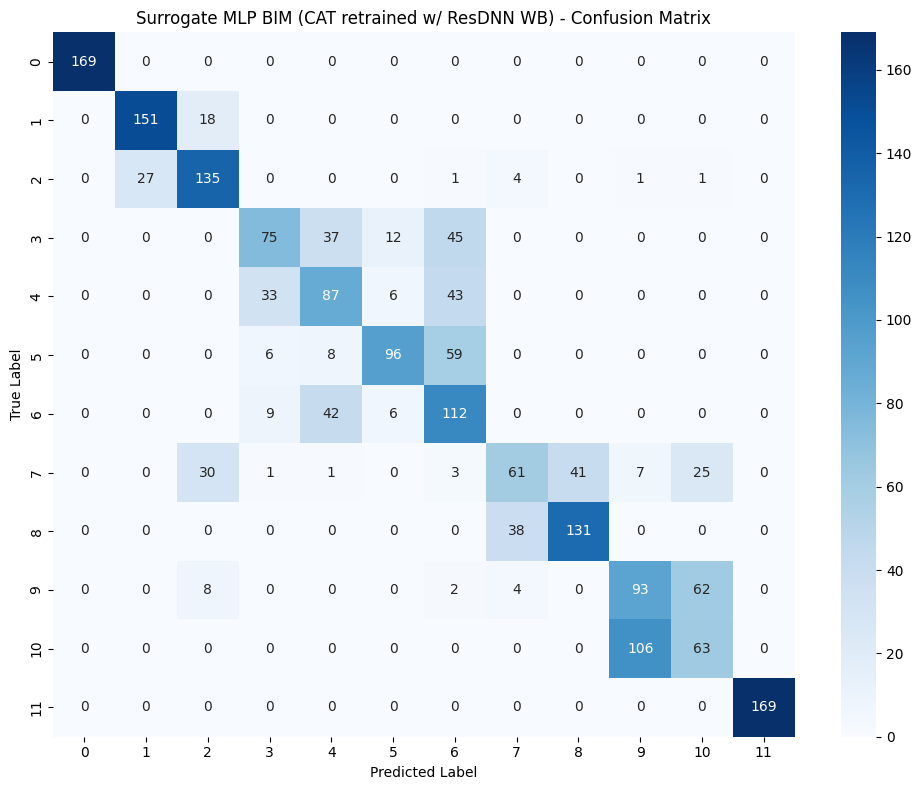

  ASR: 24.41%

--- Surrogate MLP MIM (CAT retrained w/ ResDNN WB) ---
Accuracy: 64.74%
Precision: 66.99%
Recall: 64.74%
F1 Score: 0.6442


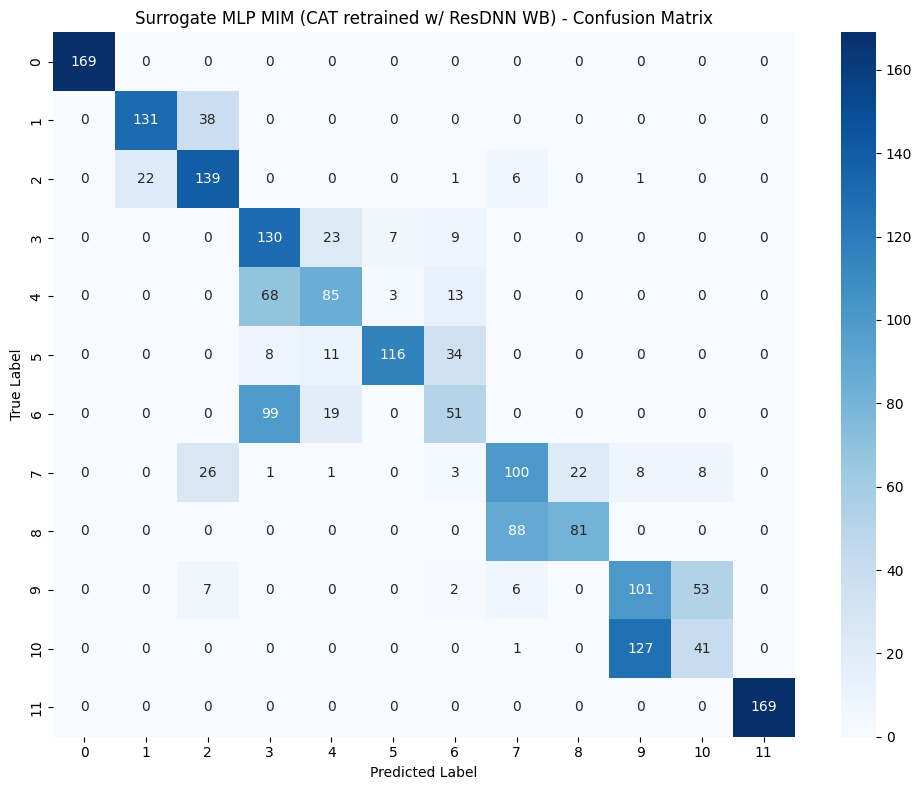

  ASR: 26.95%

--- Surrogate MLP DEEPFOOL (CAT retrained w/ ResDNN WB) ---
Accuracy: 62.33%
Precision: 64.47%
Recall: 62.33%
F1 Score: 0.6197


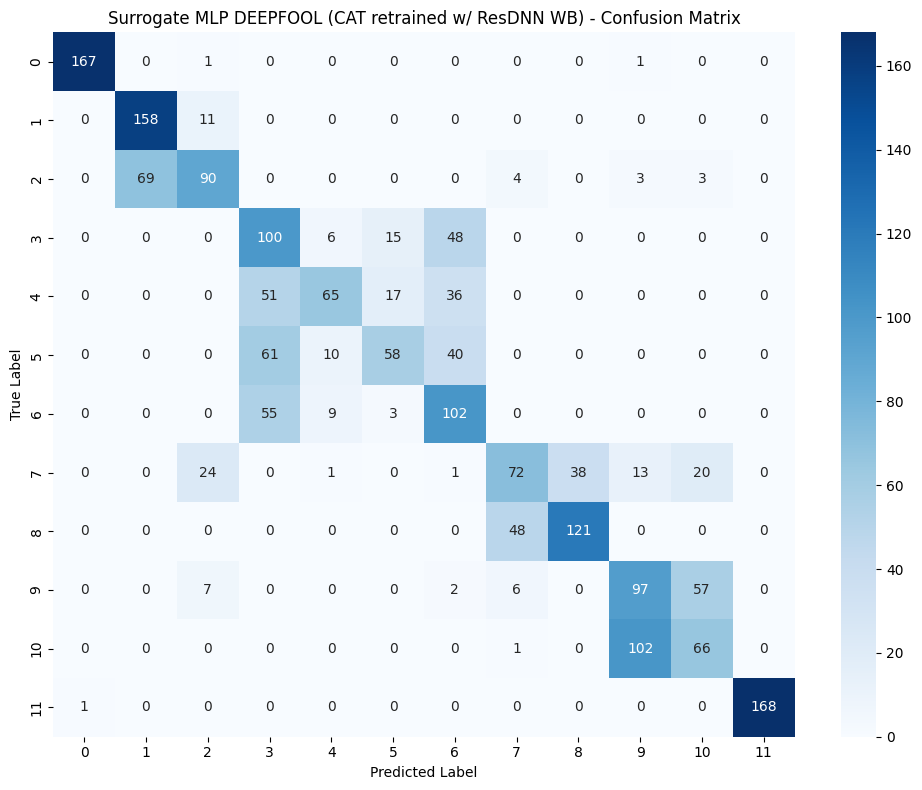

  ASR: 28.16%

--- Surrogate MLP CW (CAT retrained w/ ResDNN WB) ---
Accuracy: 75.89%
Precision: 76.07%
Recall: 75.89%
F1 Score: 0.7567


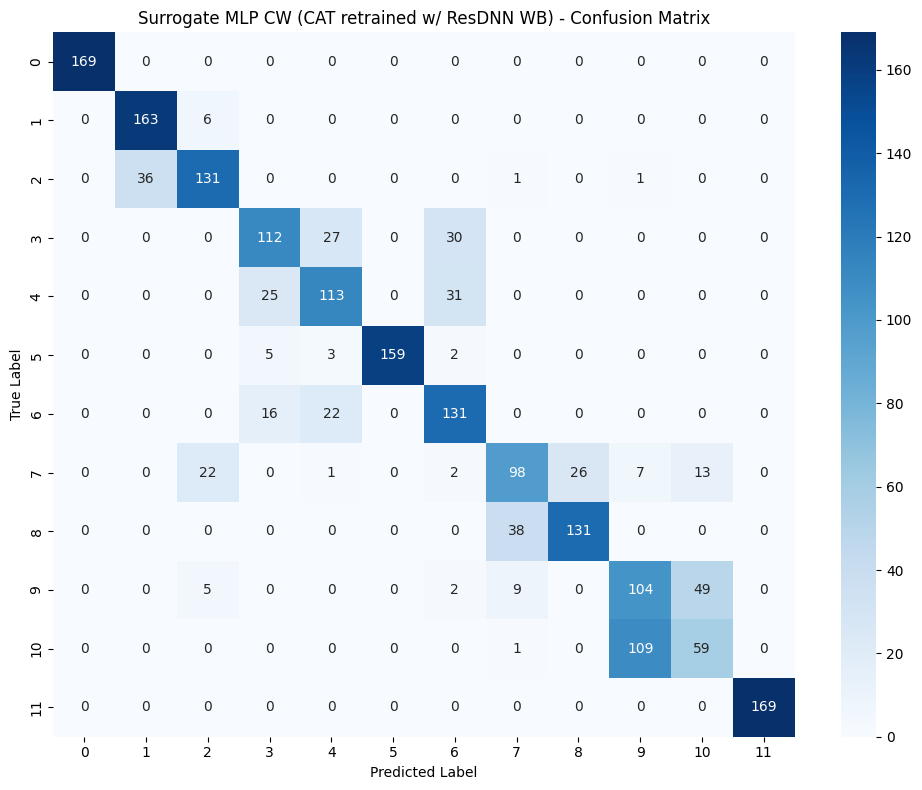

  ASR: 10.18%

=== Summary: CAT (retrained w/ ResDNN WB) vs MLP Surrogate ===
            Attack  Accuracy       F1       ASR
    surrogate_fgsm 66.420118 0.657406 24.712296
     surrogate_pgd 64.792899 0.644800 25.741975
     surrogate_bim 66.173570 0.659779 24.409449
     surrogate_mim 64.743590 0.644240 26.953362
surrogate_deepfool 62.327416 0.619743 28.164749
      surrogate_cw 75.887574 0.756656 10.175651


In [72]:
# Load retrained CAT model (trained with ResDNN whitebox adv)
cat_model_resdnn_at = joblib.load('../../defense/hybrid/models/framework_cat_multi_at.pkl')

classifier_resdnn_at = CatBoostARTClassifier(
    model=cat_model_resdnn_at,
    clip_values=(np.min(X_test), np.max(X_test)),
    nb_features=X_test.shape[1],
)

# Evaluate on clean test first
preds_clean = classifier_resdnn_at.predict(X_test)
evaluate_attack(y_test, preds_clean, 'Clean test (CAT retrained w/ ResDNN WB)')

# ── Load & evaluate on MLP surrogate adversarial samples ──
SURROGATE_DIR = '../../adv_samples/adv_eval/surrogate'
SURROGATE_ATTACKS = ['fgsm', 'pgd', 'bim', 'mim', 'deepfool', 'cw']

# Correct predictions on clean data (for ASR)
y_pred_clean = np.argmax(preds_clean, axis=1)
correct_idx = np.where(y_test == y_pred_clean)[0]

results = []

for atk in SURROGATE_ATTACKS:
    path = os.path.join(SURROGATE_DIR, f'surrogate_{atk}_adv.csv')
    if not os.path.exists(path):
        print(f'[SKIP] {path}')
        continue

    df_adv = pd.read_csv(path)
    X_adv = df_adv.drop(columns=['Label']).values.astype(np.float32)

    preds_adv = classifier_resdnn_at.predict(X_adv)
    evaluate_attack(y_test, preds_adv, f'Surrogate MLP {atk.upper()} (CAT retrained w/ ResDNN WB)')

    # ASR
    y_pred_adv = np.argmax(preds_adv, axis=1)
    asr = np.sum(y_pred_clean[correct_idx] != y_pred_adv[correct_idx]) / len(correct_idx) * 100

    acc = accuracy_score(y_test, y_pred_adv) * 100
    f1 = f1_score(y_test, y_pred_adv, average='macro')
    results.append({'Attack': f'surrogate_{atk}', 'Accuracy': acc, 'F1': f1, 'ASR': asr})
    print(f'  ASR: {asr:.2f}%\n')

# Summary table
df_results = pd.DataFrame(results)
print('=== Summary: CAT (retrained w/ ResDNN WB) vs MLP Surrogate ===')
print(df_results.to_string(index=False))